<a href="https://colab.research.google.com/github/danish-khan962/ADGIPS-LabFiles/blob/main/Advances%20in%20Deep%20Learning%20(ADL)%20Lab/ADL_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ADVANCES IN DEEP LEARNING LAB FILE**

In [ ]:
# Global import of tensorflow
import tensorflow as tf

##**EXPERIMENT-01**
---
#####**Aim**: *Implement multilayer perceptron algorithm for MNIST Hand written Digit Classification.*
---
#####**Theory:** A multilayer perceptron (MLP) is a feedforward neural network with input, hidden, and output layers. It learns using backpropagation and updates weights using gradient descent.
######Loss is minimized using: `L=−∑ylog(y^​)`
---

#####**Code:**

In [ ]:
# Importing dependencies
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
# Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Flatten Images
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [ ]:
# Building the base model
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiling the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9309 - loss: 0.2388
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9681 - loss: 0.1038
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0735
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9828 - loss: 0.0545
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9861 - loss: 0.0435


In [ ]:

# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy: ", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.0880
Test Accuracy:  0.9740999937057495


<Axes: >

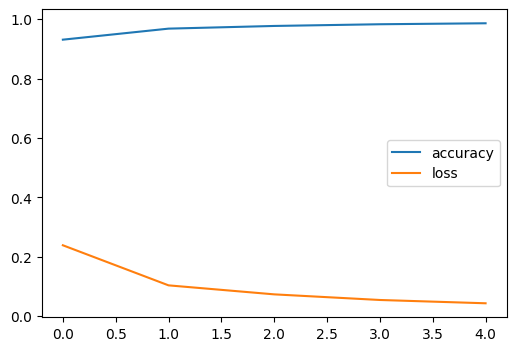

In [ ]:
# Plotting the loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned how MLP works for image classification.
* Understood preprocessing and model training steps.
* Gained knowledge of neural network layers and accuracy evaluation.
---

##**EXPERIMENT-02**
---
#####**Aim**: *Design a neural network for classifying movie reviews (Binary Classification) using IMDB dataset.*
---
#####**Theory:** Binary classification predicts output as 0 or 1 using sigmoid activation. Neural network learns by minimizing binary cross-entropy loss.
#####oss is minimized using: `L=−[ylog(y^​)+(1−y)log(1−y^​)]`
---

#####**Code:**

In [ ]:
# Importing Dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Pad sequences
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

In [ ]:
# Building the base model
model = models.Sequential([
    layers.Embedding(10000, 128, input_length=200),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compiling the model
model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 71ms/step - accuracy: 0.8158 - loss: 0.3868
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.9802 - loss: 0.0578
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.9961 - loss: 0.0120
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9975 - loss: 0.0080
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.9926 - loss: 0.0215


782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8360 - loss: 0.8174
Test Accuracy: 0.8360000252723694


<Axes: >

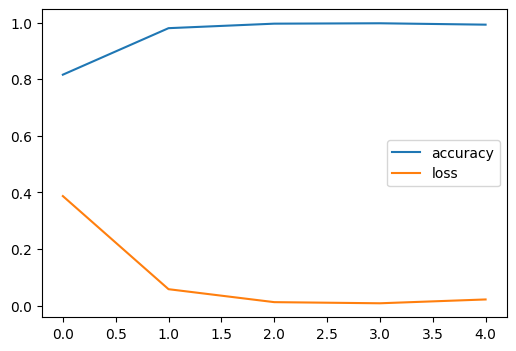

In [ ]:
# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# Plotting the loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))


#####**Learning Outcomes:**
* Learned binary classification using neural networks.
* Understood text preprocessing using padding.
* Gained knowledge of sigmoid activation and binary loss.
---

##**EXPERIMENT-03**
---
#####**Aim**: *Design a neural network for classifying news wires (Multi class classification) using Reuters dataset.*
---
#####**Theory:** Multi-class classification predicts one class among many using softmax activation.Neural network minimizes categorical cross-entropy loss during training.
######Loss is minimized using: `L=−∑yi​log(y^​i​)`
---

#####**Code:**

In [ ]:
# Importing dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=200)
x_test = pad_sequences(x_test, maxlen=200)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Building the base model
model = models.Sequential([
    layers.Embedding(10000, 128, input_length=200),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(46, activation='softmax')
])

# Compiling the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


281/281 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.5945 - loss: 1.6554
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.8568 - loss: 0.6318
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.9466 - loss: 0.2670
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.9526 - loss: 0.1851
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9501 - loss: 0.1624


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6955 - loss: 1.4120
Test Accuracy:  0.6954585909843445


<Axes: >

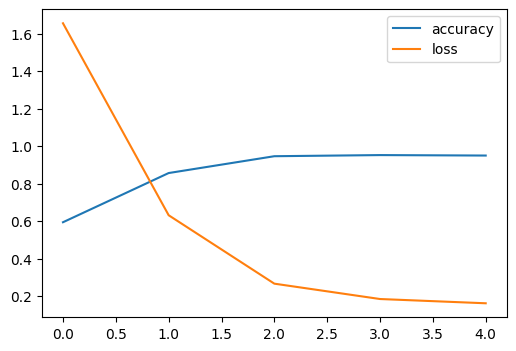

In [ ]:
# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy: ", acc)

# Plotting the loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned multi-class classification using neural networks.
* Understood softmax activation and categorical loss.
---

##**EXPERIMENT-04**
---
#####**Aim**: *Design a neural network for predicting house prices using Boston House Price dataset.*
---
#####**Theory:** Regression predicts continuous output values using linear activation. Neural network minimizes Mean Squared Error (MSE) during training.
######Loss is minimized using: `L=n1​∑(y−y^​)2`
---

#####**Code:**

In [ ]:
# Importing Dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import boston_housing
from sklearn.preprocessing import StandardScaler

# Loading the dataset
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

In [ ]:
# Normalize data
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
# Building the base model
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(13,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Compiling the model
model.compile(loss = tf.keras.losses.MeanSquaredError(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['mae'])

# Training the model
history = model.fit(x_train, y_train, epochs=50, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - loss: 564.9523 - mae: 21.8657
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 528.3217 - mae: 20.9444
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 481.8235 - mae: 19.7670
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 418.7680 - mae: 18.1382
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 338.9062 - mae: 16.0194
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 246.6061 - mae: 13.3003
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 159.0916 - mae: 10.1524 
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 95.4689 - mae: 7.4949  
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 65.5531 - mae: 6.1545
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50.2712 - mae: 5.3478 
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 40.2442 - mae: 4.7058 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 34.0932 - mae: 4.2672 
Epoch 13/50
1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 23.1328 - mae: 3.2132
Mean Absolute Error:  3.213179588317871


<Axes: >

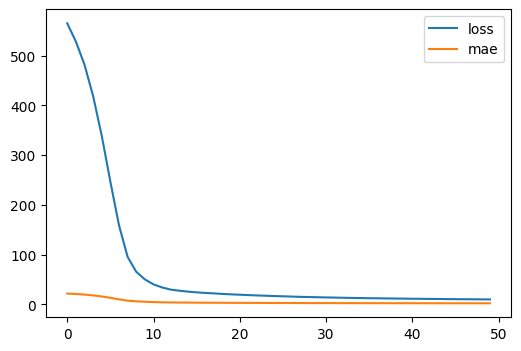

In [ ]:

# Evaluating the model
loss, mae = model.evaluate(x_test, y_test)
print("Mean Absolute Error: ", mae)

# Plotting loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned regression using neural networks.
* Understood normalization and continuous prediction.
---

##**EXPERIMENT-05**
---
#####**Aim**: *Build a Convolutional Neural Network for MNIST hand written digit classification.*
---
#####**Theory:** CNN uses convolution layers to extract spatial features from images. Pooling reduces dimensions and helps in feature selection.
######Loss is minimized using cross-entropy: `L=−∑ylog(y^​)`
---

#####**Code:**

In [ ]:
# Importing Dependency
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# Loading the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
# Building the base model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiling the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9531 - loss: 0.1511
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9854 - loss: 0.0479
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9894 - loss: 0.0341
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9921 - loss: 0.0248
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9944 - loss: 0.0174


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9909 - loss: 0.0298
Test Accuracy: 0.9908999800682068


<Axes: >

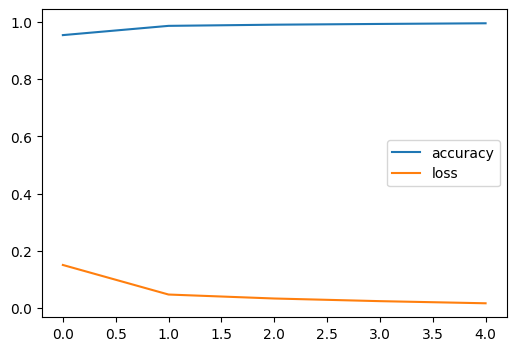

In [ ]:
# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# Plotting loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned CNN architecture for image classification.
* Gained knowledge of convolutional layers, pooling layers and feature extraction.
---

##**EXPERIMENT-06**
---
#####**Aim**: *Build a Convolutional Neural Network for simple image (dogs and cats) classification.*
---
#####**Theory:** CNN extracts image features using convolution and pooling layers. Binary classification uses sigmoid activation for output.
######Loss is minimized using cross-entropy: `L=−[ylog(y^​)+(1−y)log(1−y^​)]`
---

#####**Code:**

In [1]:
# Importing Dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Downloading the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kaggle-cat-vs-dog-dataset' dataset.
Path to dataset files: /kaggle/input/kaggle-cat-vs-dog-dataset


In [3]:
# Data preprocessing
train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 24959 images belonging to 2 classes.


In [4]:
# Building the base model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compiling the model
model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(train_data, epochs=10, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
 14/780 ━━━━━━━━━━━━━━━━━━━━ 2:46 217ms/step - accuracy: 0.4786 - loss: 0.8890

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


780/780 ━━━━━━━━━━━━━━━━━━━━ 179s 224ms/step - accuracy: 0.6521 - loss: 0.6084
Epoch 2/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.7751 - loss: 0.4716
Epoch 3/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.8135 - loss: 0.4055
Epoch 4/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.8475 - loss: 0.3465
Epoch 5/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.8783 - loss: 0.2829
Epoch 6/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.9160 - loss: 0.2060
Epoch 7/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.9482 - loss: 0.1347
Epoch 8/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.9725 - loss: 0.0767
Epoch 9/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.9848 - loss: 0.0477
Epoch 10/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.9895 - loss: 0.0354


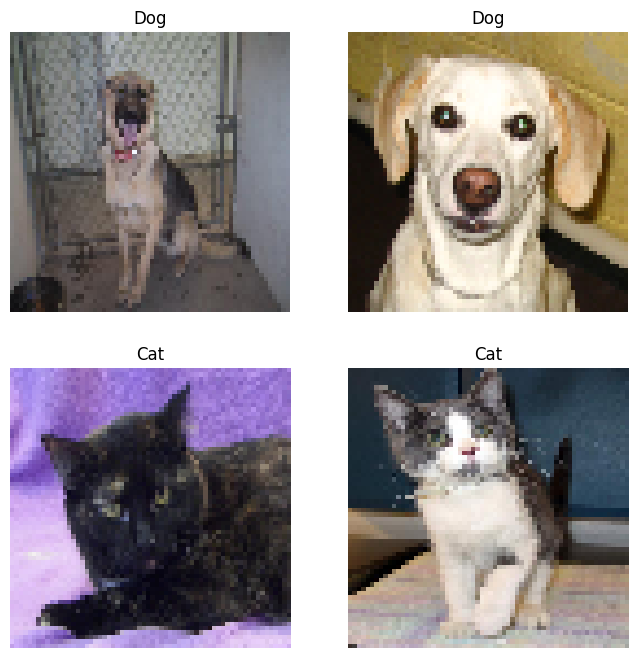

In [12]:
import numpy as np
import matplotlib.pyplot as plt
images, labels = next(train_data)
# Take 4 random images
indices = np.random.choice(len(images), 4)
plt.figure(figsize=(8,8))
for i, idx in enumerate(indices):
    img = images[idx]
    # Predict
    pred = model.predict(img.reshape(1,64,64,3), verbose=0)
    label = "Dog" if pred[0][0] > 0.5 else "Cat"
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
plt.show()

#####**Learning Outcomes:**
* Learned CNN for real-world image classification.
* Gained knowledge of binary classification on images.
---

##**EXPERIMENT-07**
---
#####**Aim**: *Use a pre-trained convolutional neural network (VGG16) for image classification*
---
#####**Theory:** Pre-trained models use transfer learning to reuse learned features. VGG16 is trained on ImageNet and extracts high-level image features.
######Loss is minimized using cross-entropy: `−∑ylog(y^​)`
---

#####**Code:**

In [13]:
# Importing dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
# Data Preprocessing
train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_data = train_datagen.flow_from_directory('/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages',
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='binary')

test_data = test_datagen.flow_from_directory('/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages',
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='binary')


Found 24959 images belonging to 2 classes.
Found 24959 images belonging to 2 classes.


In [17]:
# Loading VGG16 base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freezing base layers
for layer in base_model.layers:
  layer.trainable = False

# BUilding base model
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compiling the model
model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])
history = model.fit(train_data, epochs=5, verbose=1)
print("Training done successfully..")

Epoch 1/5
166/780 ━━━━━━━━━━━━━━━━━━━━ 2:00 196ms/step - accuracy: 0.7615 - loss: 0.6548

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


780/780 ━━━━━━━━━━━━━━━━━━━━ 189s 223ms/step - accuracy: 0.9069 - loss: 0.2261
Epoch 2/5
780/780 ━━━━━━━━━━━━━━━━━━━━ 158s 202ms/step - accuracy: 0.9444 - loss: 0.1365
Epoch 3/5
780/780 ━━━━━━━━━━━━━━━━━━━━ 158s 202ms/step - accuracy: 0.9601 - loss: 0.1034
Epoch 4/5
780/780 ━━━━━━━━━━━━━━━━━━━━ 158s 203ms/step - accuracy: 0.9682 - loss: 0.0822
Epoch 5/5
780/780 ━━━━━━━━━━━━━━━━━━━━ 158s 203ms/step - accuracy: 0.9756 - loss: 0.0629
Training done successfully..


576/780 ━━━━━━━━━━━━━━━━━━━━ 41s 202ms/step - accuracy: 0.9827 - loss: 0.0429

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


780/780 ━━━━━━━━━━━━━━━━━━━━ 159s 203ms/step - accuracy: 0.9832 - loss: 0.0426
Test Accuracy: 0.9832124710083008


<Axes: >

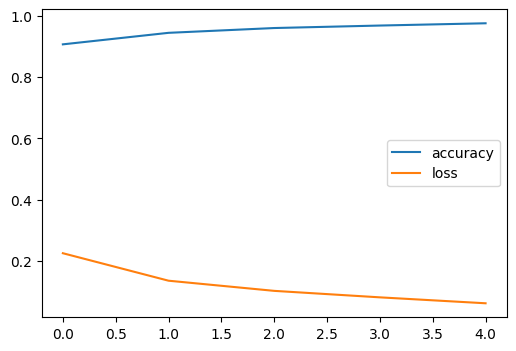

In [21]:
# Evaluating the model
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

# Plotting loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned transfer learning using VGG16.
* Understood freezing layers and feature extraction.
---

##**EXPERIMENT-08**
---
#####**Aim**: *Implement one hot encoding of words or characters.*
---
#####**Theory:** One-hot encoding converts categorical data into binary vectors. Each word/character is represented as a vector with one 1 and rest 0.
######For a word index 𝑖: `xi​=[0,0,...,1,...,0]`
---

#####**Code:**

In [27]:
import numpy as np

# Sample text
text = ["cat", "dog", "bat"]

# Create vocabulary
vocab = list(set("".join(text)))
char_to_index = {char: idx for idx, char in enumerate(vocab)}

# One-hot encoding for characters
one_hot = []

for word in text:
    word_encoding = []
    for char in word:
        vector = [0] * len(vocab)
        vector[char_to_index[char]] = 1
        word_encoding.append(vector)
    one_hot.append(word_encoding)

print("Vocabulary:", vocab)
print("One hot encoding: \n", one_hot)

Vocabulary: ['g', 'o', 'b', 'a', 't', 'd', 'c']
One hot encoding: 
 [[[0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0]], [[0, 0, 0, 0, 0, 1, 0], [0, 1, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0]], [[0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0]]]


#####**Learning Outcomes:**
* Learned how to convert text into numerical form.
* Gained knowledge of basic NLP preprocessing technique.
---

##**EXPERIMENT-09**
---
#####**Aim**: *Implement word embeddings for IMDB dataset.*
---
#####**Theory:** Word embeddings represent words as dense vectors instead of sparse one-hot vectors. Embedding layer learns word representations during training.
######Each word is mapped to a vector: `wi​→R^d`
---

#####**Code:**

In [29]:
# Importing dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [30]:
# Loading the dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences
x_train = pad_sequences(x_train, maxlen = 200)
x_test = pad_sequences(x_test, maxlen = 200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [32]:
# Building the model
model = models. Sequential([
    layers.Embedding(input_dim=100000, output_dim=128, input_length=200),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(1, activation = 'sigmoid')
])

# Compiling the model
model.compile(loss = tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=5, verbose=1)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8106 - loss: 0.3956
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9773 - loss: 0.0662
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9961 - loss: 0.0129
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9996 - loss: 0.0020
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 1.0000 - loss: 2.6729e-04


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8520 - loss: 0.8298
Test Accuracy:  0.8520399928092957


<Axes: >

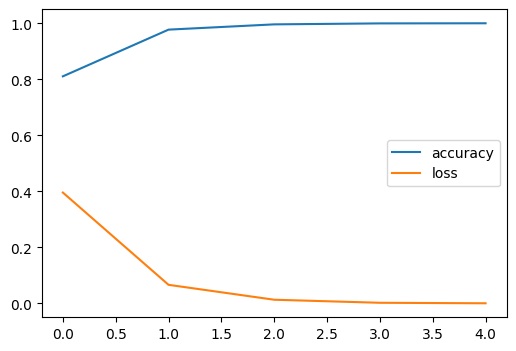

In [33]:
# Evaluating the model
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy: ", acc)

# Plotting loss curve
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(6,4))

#####**Learning Outcomes:**
* Learned concept of word embeddings.
* Gained knowledge of dense vector representation of text.
* Understood how embedding layer works.
---